
# Mini-Proyecto de **Regresión** — Base con TODOs (Fish Market)
**Objetivo:** Predecir el **peso** (`Weight`) de los peces a partir de dimensiones físicas.

**Dataset:** *Fish Market* (público).  
URL sugerida: `https://raw.githubusercontent.com/selva86/datasets/master/Fish.csv`

**Modelos a usar (regresión):**
- **KNNRegressor**
- **SVR**
- **DecisionTreeRegressor**
- **RandomForestRegressor**

> ⚠️ Qué debes completar (TODOs):
> 1) **Train/Test split** y **normalización estándar** (cuando aplique).  
> 2) **GridSearchCV** para cada modelo (4), **predicciones** y **métricas** (MSE, MAE, RMSE, MAPE, R²).  
> 3) **Comparativa final** de modelos.
>
> Debajo de cada bloque tienes una **SOLUCIÓN comentada** (`# SOLUCIÓN`) que luego puedes borrar.



## 1) Imports y configuración


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                             mean_absolute_percentage_error, root_mean_squared_error)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_curve, precision_recall_curve


# Modelos de regresión (los 4 pedidos)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")


## 2) Carga de datos


In [2]:
url = "https://raw.githubusercontent.com/Ankit152/Fish-Market/refs/heads/main/Fish.csv"
df = pd.read_csv(url)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340



## 3) EDA mínima


In [3]:
print("Shape:", df.shape)
print("\nTipos:\n", df.dtypes)
print("\nNulos por columna:\n", df.isna().sum())
display(df.describe().T)

print("\nClases de 'Species':")
print(df['Species'].value_counts())

Shape: (159, 7)

Tipos:
 Species     object
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

Nulos por columna:
 Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Weight,159.0,398.326415,357.978317,0.0000,120.00000,273.0000,650.0000,1650.000
Length1,159.0,26.247170,9.996441,7.5000,19.05000,25.2000,32.7000,59.000
Length2,159.0,28.415723,10.716328,8.4000,21.00000,27.3000,35.5000,63.400
Length3,159.0,31.227044,11.610246,8.8000,23.15000,29.4000,39.6500,68.000
Height,159.0,8.970994,4.286208,1.7284,5.94480,7.7860,12.3659,18.957
Width,159.0,4.417486,1.685804,1.0476,3.38565,4.2485,5.5845,8.142



Clases de 'Species':
Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64



## 4) Selección de variables
- **y (target):** `Weight`
- **X (features):** `Length1`, `Length2`, `Length3`, `Height`, `Width`  
(Dejamos fuera `Species` para centrarnos en un flujo de regresión con numéricas.)


In [4]:
target = "Weight"
features = ["Length1", "Length2", "Length3", "Height", "Width"]

X = df[features].copy()
y = df[target].copy()

X.head(), y.head()

(   Length1  Length2  Length3   Height   Width
 0     23.2     25.4     30.0  11.5200  4.0200
 1     24.0     26.3     31.2  12.4800  4.3056
 2     23.9     26.5     31.1  12.3778  4.6961
 3     26.3     29.0     33.5  12.7300  4.4555
 4     26.5     29.0     34.0  12.4440  5.1340,
 0    242.0
 1    290.0
 2    340.0
 3    363.0
 4    430.0
 Name: Weight, dtype: float64)


## 5) **TODO** — Train/Test split + Normalización
1. Divide en train/test (por ejemplo `test_size=0.2`, `random_state=42`).  
2. Aplica **StandardScaler** ajustando SOLO con `X_train` y transformando `X_train` y `X_test`.

> ℹ️ **Nota:** KNN y SVR requieren **escalado** para funcionar bien. Para **DT** y **RF**, usaremos los datos **sin escalar**.


In [5]:
# ============= Separación de datos en train y test =============

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (127, 5)  Test shape: (32, 5)


In [6]:
#============= Escalado de datos =============

scaler_data = StandardScaler()
X_train_scaler = scaler_data.fit_transform(X_train) 
X_test_scaler = scaler_data.transform(X_test)


## PREGUNTAS PARA RESPONDER:

1. Aparte del StandardScaler, ¿qué otros tipos de escalado conoces?

Otro de los métodos de escalado de datos es "Min-Max Scaling" que consiste en reescalar datos a un rango específico (como por ejemplo [0, 1] o [-1, 1]). Es útil en casos en los que quieres mantener la interpretación relativa de los datos y quieres que todas las variables estén en la misma escala. Un ejemplo sería una imagen de analisis médico, donde los pixeles de dicha imagen tienen valores en diferentes rangos y quieres reescalar los valores de estos pixeles.

Un segundo método sería el de "Z-score Scaling", usado cuando queremos tener una media de 0 y una desviación estandard de 1. Es útil en casos en los que quieres eliminar la influencia de las variables escaladas y centrar dichas variables alrededor de 0. Un ejemplo sería el analisis financiero, cuando escalas las categorías a comparar y el hacerlo de este modo, ayuda a comparar con mejor igualdad eliminando diferencias en el escalado de variables.

El último tipo de escalado que conozco es "Robust Scaling", usado cuando los datos contienen muchos outliers y es necesaria una normalización resistente a estos. Es útil cuando quieres asegurar que la normalización no está significativamente influenciada por los outliers y los datos extremos. Un ejemplo sería una encuenta analitica, donde las respuestas pueden incluir outliers debido a los errores o a las respuestas inusuales de los ususarios. Para ello, este método ayuda a normalizar los datos sin que estos se vean afectados por estos outliers. 

2. ¿Que diferencias hay entre ellos?

La diferencia está tanto en el modo de escalar como en la finalidad de ello.

Mientras que en "Min-Max Scaling" se escala con un rango específico que decides, en "Z-Score Scaling" se centra en hacer una campana de Gauss y normalizar los datos a una media de cero y una desviación estandar de 1 y en "Robust Scaling" normaliza hasta eliminar la influencia de outliers.

Por ello, la finalidad de cada uno es diferente. En "Min-Max Scaling", se quiere mentener la interpretación relativa,  en "Z-Score Scaling" se desea eliminar la influencia entre variables y en "Robust Scaling" se quiere eliminar la influencia de los outliers y los datos extremos.

3. ¿Por qué es importante ajustar el escalador solo con los datos de entrenamiento? 

Por que si lo haces con los datos de test, estás entrenando tu modelos con los datos a lo que vas a querer que se asemeje en tu analisis, entonces estás entrenando sobre lo que quieres obtener y no tendría sentido.

4. ¿Para que sirve la semilla aleatoria? 

Para que en procesos aleatoríos, cuando establezcas una semilla te den los mismos resultados (que siempre que se plotee se seleccionen los mismos datos para el train y el test) y no vaya seleccionando otro valores aleatorios y se haga un analisis diferente cada vez. De este modo se podrá hacer un analisis sobre los mismos datos.


## 6) Utilidad para métricas (MSE, MAE, RMSE, MAPE, R²)


In [7]:
# ============= Función para calcular métricas de regresión =============

def regression_metrics(y_test, y_pred):

    MAE= mean_absolute_error(y_test, y_pred)
    MSE= mean_squared_error(y_test, y_pred)
    RMSE= root_mean_squared_error(y_test, y_pred)
    MAPE= mean_absolute_percentage_error(y_test, y_pred)
    R_2= r2_score(y_test, y_pred)

    return {"MAE": MAE, "MSE": MSE, "RMSE": RMSE, "MAPE": MAPE, "R2": R_2}

### MÁS PREGUNTAS PARA RESPONDER:
1. ¿Que aporta cada metrica?

- MAE (Mean Absolute Error): Aporta facilidad en la interpretación de datos y no penaliza mucho los errores grandes.

- MSE (Mean Squared Error): A diferencia del anterior, penaliza más los errores grandes aportando utilidad para detectar predicciones muy poco correctas y precisas.

- RMSE (Root Mean Squared Error): Facilita la interpretación ya que la escala de esta métrica es la misma que la de las variables a estudiar Además, también penaliza los errores grandes.

- MAPE (Mean Absolute Percentage Error): Permite comparar el rendimiento entre diferentes escalas de variables.

- R^2 (Coeficiente de determinación): Aporta como de bien explica el modelo los datos.

2. ¿Cual es la más importante?

El analisis conjunto de todas las métricas es lo que mejor nos va a informar sobre un modelo. 

Sin embargo, si tuviera que seleccionar la que mejor nos informa y cual es la más importante, esta sería la RMSE ya que es la que más fácil se interpreta dada su escala y la que más destaca los grandes errores. Por añadir otra métrica, el RMSE junto la R^2 es lo que mejor nos informa sobre la eficacia y precisión del modelo.


## 7) Entrenamiento de modelos
Iremos acumulando resultados en una lista `results` para la comparativa final.


In [8]:

results = []



## 7) KNNRegressor

https://www.ibm.com/es-es/think/topics/knn

Instancia proporcionada. **Completa**: GridSearchCV (parrilla típica), `fit`, `predict`, métricas y guarda en `results` para comparar al final.


In [9]:
# ================== DATA FOR KNN ==================

X_train_knn = X_train_scaler
X_test_knn = X_test_scaler

knn = KNeighborsRegressor()

# ================== Grid Search KNN ==================
param_grid_knn = {
    'n_neighbors': [3,5,7,9,15],
    'weights': ['uniform', 'distance'], 
    'p': [1, 2] 
}

gs_knn = GridSearchCV(knn, param_grid_knn, scoring='r2', cv=5, n_jobs=-1, refit=True) 
gs_knn.fit(X_train_knn, y_train)


,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [10]:
print(round(gs_knn.best_score_, 4), gs_knn.best_params_) 

0.9738 {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}


In [11]:
# ===================== Predicción y métricas =====================
best_knn = gs_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)

mets = regression_metrics(y_test, y_pred_knn)
print(mets)

best_knnregressor = gs_knn.best_estimator_
results.append({"modelo": "KNNRegressor", **mets}) 


{'MAE': 29.097914845221382, 'MSE': 1944.8657615436455, 'RMSE': 44.10063221251647, 'MAPE': 0.08832478705564789, 'R2': 0.9863268032003921}


### MÁS PREGUNTAS PARA RESPONDER:
1. ¿Que hiperparametros son los más importantes en KNNRegressor?

Los hiperparámetro de KNN son:
- n_neighbors (k): nos indica el nº de vecinos a tener en cuenta. Estableceremos:

  - Como valores pequeño (3–5): las fronteras están muy detalladas, presenta menos bias y tiene más varianza (sensible a ruido).  
  - Como valores grande (7–25): las fronteras son suaves, presenta mayor bias y tiene menos varianza.  

- weights: Nos indica la importancia o "peso" por porximidad, hay dos tipos:

  - uniform : todos los puntos pesan lo mismo, 
  - distance : los puntos más cercanos pesan más. Este  suele mejorar cuando hay densidades desiguales o outliers.

- p (Minkowski): Es el modo de medir la distancia entre puntos. Pueden ser:

    - p=1 (Manhattan) puede ser más robusta a outliers.
    - p=2 (Euclídea): esta distancia es estándar.  
    

2. Dice el profe que este modelo realmente no tiene un entrenamiento como tal, ¿a qué se refiere?

Ya que tu no estás imponiendo ninguna condición o estableciendo nada, simplemente marcas los "vecinos" que tiene que tener en cuenta, la importancia (peso) y el tipo de distancia a tener en cuenta y hace un ranking del mejor resultado al peor y guarda el mejor valor. 

3. ¿Que otras distancias aparte de la euclidea conoces? ¿Porque pueden ser interesantes?

La Manhattan, que  mide la distancia entre dos puntos sumando las diferencias absolutas de cada coordenada. Nos puede interesar porque con la disposición de los datos puede beneficiarnos más un método, es otra forma de marcar la distancia entre puntos. 


## 7) SVR

https://www.ibm.com/es-es/think/topics/support-vector-machine

Instancia proporcionada. **Completa**: GridSearchCV (parrilla típica), `fit`, `predict`, métricas y guarda en `results` para comparar al final.


In [12]:
# ================== DATA FOR SVR ==================

X_train_svr = X_train_scaler
X_test_svr = X_test_scaler

svr = SVR()

# ================== Grid Search SVR ==================
param_grid_svr = {
    'kernel': ['rbf', 'poly', 'linear'],
    'C': [0.1, 1, 10], 
    'epsilon': [0.1, 1, 2],  
    'gamma': ['scale', 'auto'] 
}

gs_svr = GridSearchCV(svr, param_grid_svr, scoring='r2', cv=5, n_jobs=-1, refit=True) 
gs_svr.fit(X_train_svr, y_train)

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'epsilon': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'poly', ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [13]:
print(round(gs_svr.best_score_, 4), gs_svr.best_params_) 

0.831 {'C': 10, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}


In [14]:
# ===================== Predicción y métricas =====================
best_svr = gs_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_svr)

mets = regression_metrics(y_test, y_pred_svr)
print(mets)

best_svrregressor = gs_svr.best_estimator_
results.append({"modelo": "SVRRegressor", **mets}) 


{'MAE': 109.88199594862286, 'MSE': 22069.199452725974, 'RMSE': 148.55705790276667, 'MAPE': 4.53016024443912, 'R2': 0.8448445577614491}


### PREGUNTAS PARA RESPONDER:
1. ¿Qué papel juega el parámetro C en SVR?

C controla cuánto penalizamos errores en el entrenamiento de los datos del train.  
  - Para valores grande (10, 100): hay un margen estrecho, un bajo bias y hay riesgo de overfit.  
  - Pra valores pequeño (0.1, 0.01): hay un margen amplio, un bias más elevado y hay una mayor regularización.

2. ¿Y el parámetro epsilon?

Se refiere al margen de tolerancia del modelo, es decir, cuento le está permitido "equivocarse" al modelo. Para valores grandes permite errores pequeños sin penalización, mientras que en valores pequeños de epsilon se exigen más precisión.

3. ¿Qué diferencias hay entre los kernels linear, poly y rbf?

Las diferencias entre los kernels en SVR son:

- Linear: Busca una relación lineal entre las variables. Solo puede ajustar datos que se separan bien con una recta.
- Poly: Usa funciones polinómicas. Permite ajustar relaciones más complejas y curvas, según el grado del polinomio.
- Rbf (Radial Basis Function): Es el más flexible. Puede modelar relaciones no lineales y patrones complejos, adaptándose a la forma de los datos.

## 7) DecisionTreeRegressor

https://www.ibm.com/es-es/think/topics/decision-trees

Instancia proporcionada. **Completa**: GridSearchCV (parrilla típica), `fit`, `predict`, métricas y guarda en `results` para comparar al final.

In [15]:
# ================== DATA FOR DECISION TREE ==================

X_train_Dec_t = X_train_scaler
X_test_Dec_t = X_test_scaler

Dec_t = DecisionTreeRegressor(random_state=42)

# ================== Grid Search DECISION TREE ==================
param_grid_Dec_t = {
    'max_depth': [None, 3, 5, 10], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4] 
}

gs_Dec_t = GridSearchCV(Dec_t, param_grid_Dec_t, scoring='r2', cv=5, n_jobs=-1, refit=True) 
gs_Dec_t.fit(X_train_Dec_t, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [16]:
print(round(gs_Dec_t.best_score_, 4), gs_Dec_t.best_params_) 

0.9723 {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [17]:
# ===================== Predicción y métricas =====================
best_Dec_t = gs_Dec_t.best_estimator_
y_pred_Dec_t = best_Dec_t.predict(X_test_Dec_t)

mets = regression_metrics(y_test, y_pred_Dec_t)
print(mets)

best_Dec_tregressor = gs_Dec_t.best_estimator_
results.append({"modelo": "Dec_tRegressor", **mets}) 


{'MAE': 52.239843750000006, 'MSE': 7196.656473189681, 'RMSE': 84.83310953389415, 'MAPE': 0.15928677596550286, 'R2': 0.9494045798929625}


### PREGUNTAS PARA RESPONDER:
1. El profe dice que los árboles no necesitan escalado, ¿por qué?

Dado que este método busca comparaciones entre los datos no es preciso que estén escalados. Ya que no se calcula nada, el rango de las variables es indiferente. 

2. ¿Qué papel juega el parámetro `max_depth`?

Marca el número de niveles  de preguntas por los que pasa el modelo hasta hacer una predicción (o splits que realiza en los datos).

El término None se refiere a un árbol muy profundo (puede tender al overfitting), por otro lado si es poco profundo (puede producir un underfitting).

## 7) RandomForestRegressor

https://www.ibm.com/es-es/think/topics/random-forest

Instancia proporcionada. **Completa**: GridSearchCV (parrilla típica), `fit`, `predict`, métricas y guarda en `results` para comparar al final.

In [18]:
# ================== DATA FOR RANDOM FOREST REGRESSOR ==================

X_train_RFR = X_train_scaler
X_test_RFR = X_test_scaler

RFR = RandomForestRegressor(random_state=42)

# ================== Grid Search RANDOM FOREST REGRESSOR ==================
param_grid_RFR = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

gs_RFR = GridSearchCV(RFR, param_grid_RFR, scoring='r2', cv=5, n_jobs=-1, refit=True) 
gs_RFR.fit(X_train_RFR, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [19]:
print(round(gs_RFR.best_score_, 4), gs_RFR.best_params_) 

0.9663 {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


In [20]:
# ===================== Predicción y métricas =====================
best_RFR = gs_RFR.best_estimator_
y_pred_RFR = best_RFR.predict(X_test_RFR)

mets = regression_metrics(y_test, y_pred_RFR)
print(mets)

best_RFRregressor = gs_RFR.best_estimator_
results.append({"modelo": "RFRRegressor", **mets}) 


{'MAE': 46.066588062863005, 'MSE': 4587.211406791543, 'RMSE': 67.72895545327377, 'MAPE': 0.1315205132402995, 'R2': 0.9677500393257557}


### PREGUNTAS PARA RESPONDER:

1. ¿Por que 100 o 200 o 500 arboles son mejor que 1?

A mayor número de árboles, mayor diversidad de aprendizaje de cada árbol, al igual mayor compensación de errores entre árboles. Esto se refleja con una reducción del overfitting y un aumento de accuracy.

2. ¿Qué condicion deben cumplir los arboles para que el conjunto funcione bien?

Ya que se recurren a numerosos árboles, lo ideal y lógico es que sean diferentes unos a otros para poder hacer una mejor analisis con la variedad de datos. Por otro lado, que no estén correlacionados también sería más fácil que sean diferentes entre ellos.


## 8) **TODO** — Comparativa final
Ordena por **RMSE** (menor es mejor) y/o muestra todas las métricas.


In [21]:
df_res = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
display(df_res)

,modelo,MAE,MSE,RMSE,MAPE,R2
0,KNNRegressor,29.097915,1944.865762,44.100632,0.088325,0.986327
3,RFRRegressor,46.066588,4587.211407,67.728955,0.131521,0.967750
2,Dec_tRegressor,52.239844,7196.656473,84.833110,0.159287,0.949405
1,SVRRegressor,109.881996,22069.199453,148.557058,4.530160,0.844845


## 9) Comenta la jugada

1) Hablame de que significa cada metrica, que historia cuenta cada metrica en conjunto, como comparan unas metricas con otras.

La métrica MAE (Mean Absolut Error), representa el promedio de la diferencia absoluta entre los valores reales y los predichos en el conjunto de datos. Mide el promedio de los residuos en el conjunto de datos. 

La métrica MSE (Mean Square Error), representa el promedio de la diferencia al cuadrado entre los valores originales y los predichos en el conjunto de datos. Mide la varianza de los residuos.

La métrica RMSE (Root Mean Square Error) es la raíz cuadrada del error cuadrático medio. Mide la desviación estándar de los residuos.

La métrica MAPE (Mean Absolute Percentage Error) mide el error absoluto en porcentaje respecto al valor real. Permite comparar el rendimiento entre diferentes datasets o escalas.

La métrica R^2 (R^2 Score) representa la proporción de la varianza en la variable dependiente que es explicada por el modelo de regresión lineal. Es una métrica sin escala; es decir, independientemente de que los valores sean pequeños o grandes, el valor de R cuadrado será menor que uno.

¿Que tenemos que tener en cuenta sobre estos modelos? De los errores tanto MAE, MSE, RMSE y MAPE, sabemos que a mayor valor mayor diferencia entre los valores del test tenemos, por lo que es peor. Por consiguiente, a menor error, mejor modelo.

Sin embargo, en el caso del R^2, este es un valor que está entre el 0 y el 1. A mayor proximidad a 1, más perciso y más acertado serán los datos, de lo contrario (a mayor proximidad a 0) peor predicción hemos dado. 

Como comparación entre métricas podemos destacar que la única que mantiene la escala de las variables es RMSE. Por otro lado menos MAE y R^2, el resto de métricas sí tiene en cuenta los grandes errores. (Estas comparaciones las explico en la 1a pregunta del punto 6)


2) Que modelo es mejor y por qué. 

Basándonos en el analisis de las métricas de cada modelo y en la explicación dada en la pregunta anterior, podemos observar con la tabla de recopilación de resultados que el mejor modelo es KNN Regressor. Sus valores de errores son los más bajos en comparación con el resto y el R^2 es prácticamente 1, por lo que es un modelo que considero bastante preciso.

Respecto a modelo de RFR Regressor y DecisionTree Regressor sus valores de errores son más altos que en KNN pero tampoco están "tan elevados" en comparación con el último modelo. Además el valor de R^2 sigue siendo 0.967 y 0.949 respectivamente, por lo que tampoco es un valor muy próximo a 0.

Finalmente el peor modelo analizado ha sido el SV Regressor dado a su elevadisimo valor de los errores. No obstante, su R^2 es de 0.844, un valor que no es muy próximo a cero pero el gran peso de los errores nos indica que no es un buen modelo.

3) Que otras consideraciones podríamos tener en cuenta a la hora de elegir el modelo más allá de las métricas.

En analisis de datos nos mencionaron la "CP de Mallow" y por lo que entendí se emplea en modelos de regresión para evaluar si el modelo es adecuado o no.
Su cálculo se basa en la comparación del error cuadrático del modelo a entrenar (únicamente el training) con el de un modelo completo (training + test). 

La idea central es que un buen modelo debería mostrar un valor de CP reducido y próximo al número de predictores (p) más la constante, + 1, siendo 1 otra variable (que no corresponde al número 1 sino a otra variable que llamamos intercepto). 

Si el CP resulta mayor que ese valor, interpretaremos que hay un sesgo del modelo, mientras que valores mucho menores indiraría que se han dejado fuera variables relevantes, lo que también muestra un ajuste incorrecto.

Esto nos ayuda a comparar modelos con distintos conjuntos de predictores y escoger el que sea más simple y preciso. 
Además, como he mencinado antes con el valor de CP, servirá para evitar tanto el "overfitting", cuando el modelo incluye demasiadas variables innecesarias, como el "underfitting", cuando omite variables importantes. 

En modelos así se considerará mejor modelo al que se acerque más a p+1 (por debajo de este valor).

Respesto a los resultados dados para cada modelo añadimos a nuestro estudio que, aunque ninguno sea perfecto, el que considerariamos como mejor modelo sería Random Forest y Decision Tree, ya que el valor de p se acerca (por debajo) más a su correspondiente valor de CP.

Los valores del KNN también se aproxima por abajo su p al CP pero con un valor mayor y finalmente, por mucha mayor distancia el SVR.

El hecho de que se aproximen por debajo nos dice que falta ajuste en todos los modelos, pero en unos más que en otros. En el que más claro se muestra es en el SVR que habrís un "underfitting" (recordando los valores de las métricas nuestras conclusiones también eran que era el peor modelo). El modelo KNN muestra algo de sesgo, pero no muy exagerado y finalmente el Decision Tree y el Random Forest son los modelos que más equilibrio muestran.  

(El código de esto se encuentra a continuación y la pregunta que falta después de este)

In [22]:
from sklearn.linear_model import LinearRegression  # Importa regresión lineal de scikit-learn

# ================== GENERAL ==================

def sigma2_from_full_ols(X, y):
    """
    Estima σ̂^2 usando OLS con todas las variables (modelo 'full').
    """
    n, p_full = X.shape  # n = número de muestras, p_full = número de predictores
    ols = LinearRegression().fit(X, y)  # Ajusta un modelo de regresión lineal con todas las variables
    resid = y - ols.predict(X)  # Calcula los residuos (diferencia entre real y predicho)
    rss_full = np.sum(resid**2)  # Suma de residuos al cuadrado (RSS)
    dof = max(1, n - (p_full + 1))  # Grados de libertad = n - (número de parámetros + intercepto)
    return rss_full / dof  # Devuelve varianza estimada del error (σ̂^2)

def mallows_cp(y_true, y_pred, sigma2, p_eff):
    """
    CP = SSE/σ̂^2 - (n - 2 p_eff)
    """
    n = len(y_true)  # Número de observaciones
    sse = np.sum((y_true - y_pred)**2)  # Suma de errores al cuadrado para el modelo evaluado
    return sse / sigma2 - (n - 2 * p_eff)  # Fórmula de Cp de Mallows


In [23]:
# ================== Cp de Mallows para KNN ==================

def peff_knn(n_samples, k):
    # Aproximación de grados de libertad efectivos en KNN
    # Se usa el número de vectores de soporte del modelo entrenado
    return min(n_samples - 1, max(1, n_samples / max(1, k)))  
    # Devuelve n/k como estimación de p_eff
    # Se asegura de que el valor esté entre 1 y n-1 para evitar problemas

# ================== Cálculo para tu mejor modelo KNN ==================

sigma2 = sigma2_from_full_ols(X_train_knn, y_train)  # Estima σ̂^2 usando el modelo OLS con todas las variables de entrenamiento (modelo full)

k_opt_KNN = best_knnregressor.n_neighbors  # Obtiene el número de vecinos (k) del mejor modelo KNN encontrado con GridSearch

p_eff_KNN = peff_knn(len(X_train_knn), k_opt_KNN)  # Calcula los grados de libertad efectivos para KNN usando la heurística n/k

Cp_knn = mallows_cp(y_test, y_pred_knn, sigma2, p_eff_KNN)  # Calcula el Cp de Mallows para el mejor modelo KNN en el conjunto de test


In [24]:
# ================== Cp de Mallows para SVR ==================

def peff_svr(model):
    # Aproximación de grados de libertad efectivos en SVR
    # Se usa el número de vectores de soporte del modelo entrenado
    return max(1, len(model.support_))  

# Estimar σ̂^2 desde un modelo OLS con todas las variables de entrenamiento (modelo full)
sigma2 = sigma2_from_full_ols(X_train_svr, y_train)

# Grados de libertad efectivos para el SVR óptimo (número de vectores de soporte)
p_eff_SVR = peff_svr(best_svrregressor)

# Calcular Mallows Cp en el conjunto de test para el SVR
Cp_svr = mallows_cp(y_test, y_pred_svr, sigma2, p_eff_SVR)


In [25]:
# ================== Cp de Mallows para Decision Tree ==================

def peff_decision_tree(model):
    # Aproximación de grados de libertad efectivos en un árbol de decisión
    # Se toma como medida el número de hojas (nodos terminales) del árbol
    return getattr(model.tree_, "n_leaves", 1)

# Estimar σ̂^2 desde un modelo OLS con todas las variables de entrenamiento (modelo full)
sigma2 = sigma2_from_full_ols(X_train_Dec_t, y_train)

# Grados de libertad efectivos para el Decision Tree óptimo (número de hojas)
p_eff_dt = peff_decision_tree(best_Dec_tregressor)

# Calcular Mallows Cp en el conjunto de test para el Decision Tree
Cp_Dec_t = mallows_cp(y_test, y_pred_Dec_t, sigma2, p_eff_dt)


In [26]:
# ================== Cp de Mallows para Random Forest ==================

def peff_random_forest(model):
    # Calcula los grados de libertad efectivos en un Random Forest
    # Para ello obtiene el número de hojas de cada árbol y luego calcula la media
    leaves = [est.tree_.n_leaves for est in model.estimators_]
    return max(1, int(np.mean(leaves)))  # Se asegura de que el valor mínimo sea 1

# Estimar σ̂^2 desde un modelo OLS con todas las variables de entrenamiento (modelo full)
sigma2 = sigma2_from_full_ols(X_train_RFR, y_train)

# Grados de libertad efectivos para el Random Forest óptimo (promedio de hojas por árbol)
p_eff_rf = peff_random_forest(best_RFRregressor)

# Calcular Mallows Cp en el conjunto de test para el Random Forest
Cp_RFR = mallows_cp(y_test, y_pred_RFR, sigma2, p_eff_rf)


In [27]:
results_cp = [
    {"Modelo": "KNN", "p_eff": p_eff_KNN, "Cp_Mallows": Cp_knn},
    {"Modelo": "SVR", "p_eff": p_eff_SVR, "Cp_Mallows": Cp_svr},
    {"Modelo": "Decision Tree", "p_eff": p_eff_dt, "Cp_Mallows": Cp_Dec_t},
    {"Modelo": "Random Forest", "p_eff": p_eff_rf, "Cp_Mallows": Cp_RFR}
]

df_cp = pd.DataFrame(results_cp)
display(df_cp)

,Modelo,p_eff,Cp_Mallows
0,KNN,42.333333,56.820912
1,SVR,125.000000,265.139950
2,Decision Tree,26.000000,35.372104
3,Random Forest,32.000000,41.798313


4) Que info útil nos ofrecen los modelos entrenados. 

Nos informan sobre como de ajustado y preciso es el entrenamiento que hacemos sobre los datos del train. Unos modelos son mejores, como podemos observar y hemos analizado en las preguntas anteriores. Unos modelos tienen una técticas propias de estos que por ejemplo requieren un escalado previo (como el KNN o el SVR) y otros no (como el Decision Tree y el Rndom Forest), pero no dejan de ser diferentes formas de analizar la regresión de un modelo.


## 10) Extensiones
- Añadir `Species` con One-Hot Encoding y comparar.

A continuación se muestra el código y la tabla con Hot Encoding (y debajo de esta de nuevo la realizada anteriormente sin las 'Species')

Podemos observar, antes de aplicar el One-Hot Encoding a la variable Species, el mejor modelo era KNN Regressor, con los errores más bajos y un R^2 cercano a 1, seguido de Random Forest y Decision Tree, que aunque menos precisos, mantenían un rendimiento aceptable. SVR lo considerabamos el peor debido a sus errores muy elevados y su R^2 más bajo.

Sin embargo, tras añadir Species mediante "Hot Encoding", nuestro analisis es diferente. Random Forest pasa a ser el mejor modelo ya que aprovechar mejor la información categórica, le sigue el modelo KNN y el Decision Tree y SVR, aunque mejora respecto a antes, sigue siendo el peor modelo. 

En conclusión, al añadir las 'Species' resulta, como era de esperar, mejor para todos los modelos dado el mayor uso de información y como hemos podido observar afecta bastante al rendimiento de los modelos.

(A continuación esta el código y debajo de este el resto de preguntas)

In [28]:
# ================== Species con One-Hot Encoding ==================

# ================== Codificación One-Hot de Species ==================
df_encoded = pd.get_dummies(df, columns=["Species"], drop_first=False)

In [29]:
# ================== Features y target ==================
features_encoded = [col for col in df_encoded.columns if col != "Weight"]
X_enc = df_encoded[features_encoded]
y_enc = df_encoded["Weight"]

In [30]:
# ================== Train/Test split ==================
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42
)

In [31]:
# ================== Escalado de datos ==================
scaler_enc = StandardScaler()
X_train_enc_scaler = scaler_enc.fit_transform(X_train_enc)
X_test_enc_scaler = scaler_enc.transform(X_test_enc)

In [32]:
# ================== Entrenamiento y evaluación de modelos ==================
results_enc = []

In [33]:
# ================== KNNRegressor ==================  
knn_enc = KNeighborsRegressor()
param_grid_knn = {
    'n_neighbors': [3,5,7,9,15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
gs_knn_enc = GridSearchCV(knn_enc, param_grid_knn, scoring='r2', cv=5, n_jobs=-1, refit=True)
gs_knn_enc.fit(X_train_enc_scaler, y_train_enc)
best_knn_enc = gs_knn_enc.best_estimator_
y_pred_knn_enc = best_knn_enc.predict(X_test_enc_scaler)
mets_knn_enc = regression_metrics(y_test_enc, y_pred_knn_enc)
results_enc.append({"modelo": "KNNRegressor + Species", **mets_knn_enc})

In [34]:
# ================== SVR ==================
svr_enc = SVR()
param_grid_svr = {
    'kernel': ['rbf', 'poly', 'linear'],
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 1, 2],
    'gamma': ['scale', 'auto']
}
gs_svr_enc = GridSearchCV(svr_enc, param_grid_svr, scoring='r2', cv=5, n_jobs=-1, refit=True)
gs_svr_enc.fit(X_train_enc_scaler, y_train_enc)
best_svr_enc = gs_svr_enc.best_estimator_
y_pred_svr_enc = best_svr_enc.predict(X_test_enc_scaler)
mets_svr_enc = regression_metrics(y_test_enc, y_pred_svr_enc)
results_enc.append({"modelo": "SVRRegressor + Species", **mets_svr_enc})

In [35]:
# ================== DecisionTreeRegressor ==================
dt_enc = DecisionTreeRegressor(random_state=42)
param_grid_dt = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
gs_dt_enc = GridSearchCV(dt_enc, param_grid_dt, scoring='r2', cv=5, n_jobs=-1, refit=True)
gs_dt_enc.fit(X_train_enc, y_train_enc)  # Árboles no requieren escalado
best_dt_enc = gs_dt_enc.best_estimator_
y_pred_dt_enc = best_dt_enc.predict(X_test_enc)
mets_dt_enc = regression_metrics(y_test_enc, y_pred_dt_enc)
results_enc.append({"modelo": "DecisionTreeRegressor + Species", **mets_dt_enc})

In [36]:
# ================== RandomForestRegressor ==================
rf_enc = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}
gs_rf_enc = GridSearchCV(rf_enc, param_grid_rf, scoring='r2', cv=5, n_jobs=-1, refit=True)
gs_rf_enc.fit(X_train_enc, y_train_enc)  # RF no requiere escalado
best_rf_enc = gs_rf_enc.best_estimator_
y_pred_rf_enc = best_rf_enc.predict(X_test_enc)
mets_rf_enc = regression_metrics(y_test_enc, y_pred_rf_enc)
results_enc.append({"modelo": "RandomForestRegressor + Species", **mets_rf_enc})

In [37]:
# ================== Comparativa final ==================

# Tabla con 'Species'
df_res_enc = pd.DataFrame(results_enc).sort_values(by="RMSE", ascending=True)
display(df_res_enc)

#Tabla sin 'Species' (calculada anteriormente)
df_res = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
display(df_res)

,modelo,MAE,MSE,RMSE,MAPE,R2
3,RandomForestRegressor + Species,44.952870,4334.003385,65.833148,0.127054,0.969530
0,KNNRegressor + Species,47.435231,6559.665139,80.991760,0.136460,0.953883
2,DecisionTreeRegressor + Species,48.371094,6914.255223,83.152001,0.153510,0.951390
1,SVRRegressor + Species,62.588948,9212.191194,95.980160,0.754314,0.935235


,modelo,MAE,MSE,RMSE,MAPE,R2
0,KNNRegressor,29.097915,1944.865762,44.100632,0.088325,0.986327
3,RFRRegressor,46.066588,4587.211407,67.728955,0.131521,0.967750
2,Dec_tRegressor,52.239844,7196.656473,84.833110,0.159287,0.949405
1,SVRRegressor,109.881996,22069.199453,148.557058,4.530160,0.844845


- ¿Que columnas podriamos crear/eliminar... feature engineering?

Se podría añadir alguna columna del tipo volumen del pez que fuera el producto del peso, el ancho y el largo de cada pez. (añadida en el codigo de a continuación)

A continuación y con la comparación final podremos observar que únicamente se mantiene como el mejor modelo el KNN, mientras que en segunda opción ahora tenemos el Random Forest Regressor, seguido el SVR y finalmente, como peor modelo, El Decision Tree Regressor. Esto no ha variado mucho las métricas pero si lo suficiente y de modo que ha hecho cambiar el orden de preferencia del modelo.

In [38]:
# Añadimos nueva columna 'Volume' 
df["Volume"] = df["Length3"] * df["Height"] * df["Width"]
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,1389.312000
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,1676.497306
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,1807.761723
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,1900.070253
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,2172.174864


In [39]:
# Realización de nuevo del analisis pero añadiendo la nueva columna 
# Train/Test 
features_volume = features + ['Volume']
X_volume = df[features_volume].copy()
y = df[target].copy()

X_train_vol, X_test_vol, y_train_vol, y_test_vol = train_test_split(
    X_volume, y, test_size=0.2, random_state=42
)

scaler_vol = StandardScaler()
X_train_vol_scaler = scaler_vol.fit_transform(X_train_vol)
X_test_vol_scaler = scaler_vol.transform(X_test_vol)

In [40]:
# Almacenamos nuevos resultados
results_vol = []

In [41]:
# KNNRegressor
knn_vol = KNeighborsRegressor()
gs_knn_vol = GridSearchCV(
    knn_vol,
    param_grid_knn,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    refit=True
)
gs_knn_vol.fit(X_train_vol_scaler, y_train_vol)
best_knn_vol = gs_knn_vol.best_estimator_
y_pred_knn_vol = best_knn_vol.predict(X_test_vol_scaler)
mets_knn_vol = regression_metrics(y_test_vol, y_pred_knn_vol)
results_vol.append({"modelo": "KNNRegressor + Volume", **mets_knn_vol})

In [42]:
# SVR
svr_vol = SVR()
gs_svr_vol = GridSearchCV(
    svr_vol,
    param_grid_svr,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    refit=True
)
gs_svr_vol.fit(X_train_vol_scaler, y_train_vol)
best_svr_vol = gs_svr_vol.best_estimator_
y_pred_svr_vol = best_svr_vol.predict(X_test_vol_scaler)
mets_svr_vol = regression_metrics(y_test_vol, y_pred_svr_vol)
results_vol.append({"modelo": "SVRRegressor + Volume", **mets_svr_vol})

In [43]:
# DecisionTreeRegressor
dt_vol = DecisionTreeRegressor(random_state=42)
gs_dt_vol = GridSearchCV(
    dt_vol,
    param_grid_Dec_t,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    refit=True
)
gs_dt_vol.fit(X_train_vol, y_train_vol)  # Árboles no requieren escalado
best_dt_vol = gs_dt_vol.best_estimator_
y_pred_dt_vol = best_dt_vol.predict(X_test_vol)
mets_dt_vol = regression_metrics(y_test_vol, y_pred_dt_vol)
results_vol.append({"modelo": "DecisionTreeRegressor + Volume", **mets_dt_vol})

In [44]:
# RandomForestRegressor
rf_vol = RandomForestRegressor(random_state=42)
gs_rf_vol = GridSearchCV(
    rf_vol,
    param_grid_RFR,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    refit=True
)
gs_rf_vol.fit(X_train_vol, y_train_vol)  # RF no requiere escalado
best_rf_vol = gs_rf_vol.best_estimator_
y_pred_rf_vol = best_rf_vol.predict(X_test_vol)
mets_rf_vol = regression_metrics(y_test_vol, y_pred_rf_vol)
results_vol.append({"modelo": "RandomForestRegressor + Volume", **mets_rf_vol})

In [45]:
# Tabla final de nuevos resultados
df_res_vol = pd.DataFrame(results_vol).sort_values(by="RMSE", ascending=True)
display(df_res_vol)

# Tabla inicial de resultados
df_res = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
display(df_res)

,modelo,MAE,MSE,RMSE,MAPE,R2
0,KNNRegressor + Volume,29.157379,2112.216421,45.958856,0.089586,0.985150
3,RandomForestRegressor + Volume,40.711689,3957.322474,62.907253,0.108502,0.972178
1,SVRRegressor + Volume,56.138623,7050.874805,83.969487,1.488609,0.950429
2,DecisionTreeRegressor + Volume,54.539807,7548.803221,86.883849,0.164097,0.946929


,modelo,MAE,MSE,RMSE,MAPE,R2
0,KNNRegressor,29.097915,1944.865762,44.100632,0.088325,0.986327
3,RFRRegressor,46.066588,4587.211407,67.728955,0.131521,0.967750
2,Dec_tRegressor,52.239844,7196.656473,84.833110,0.159287,0.949405
1,SVRRegressor,109.881996,22069.199453,148.557058,4.530160,0.844845


Si se tuviera que eliminar una columna sería de una categoría que no nos aportada información de otra categoría y en general en el entrene del modelo, es decir, que no esté correlacionada (que su índice de correlación sea bajo). Esto de podría observar con un mapa térmico, que como podemos analizar, dado el elevado valor de correlación de las variables no sería lógico eliminar una de las columnas, todas aportan información relevante en el analisis.

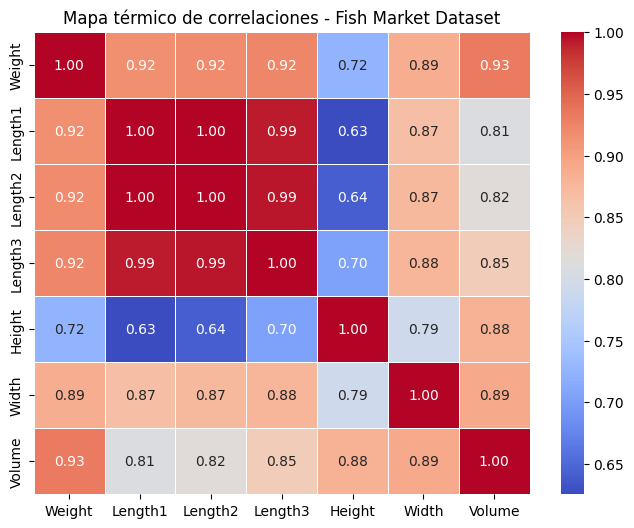

In [46]:
import seaborn as sns

# ================== Calculo de la matriz de correlación ==================
corr = df.corr(numeric_only=True)

# ================== Mapa térmico ==================
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa térmico de correlaciones - Fish Market Dataset")
plt.show()


También se pueden transformar las columnas aplicando métodos de transformación como el logarítmico o normalizaciones. En nuestro caso hemos escalado los datos en algunos modelos.

Todos estos cambios se realizarian siempre y cuando mejoren la capacidad y eficacia del modelo.

- ¿Sabrias dibujar un decission tree?

Si, a nivel de programación se encuentra debajo de la comparación de las tablas de resultados. Por otro lado también sabría realizarlo a papel y no a programación.

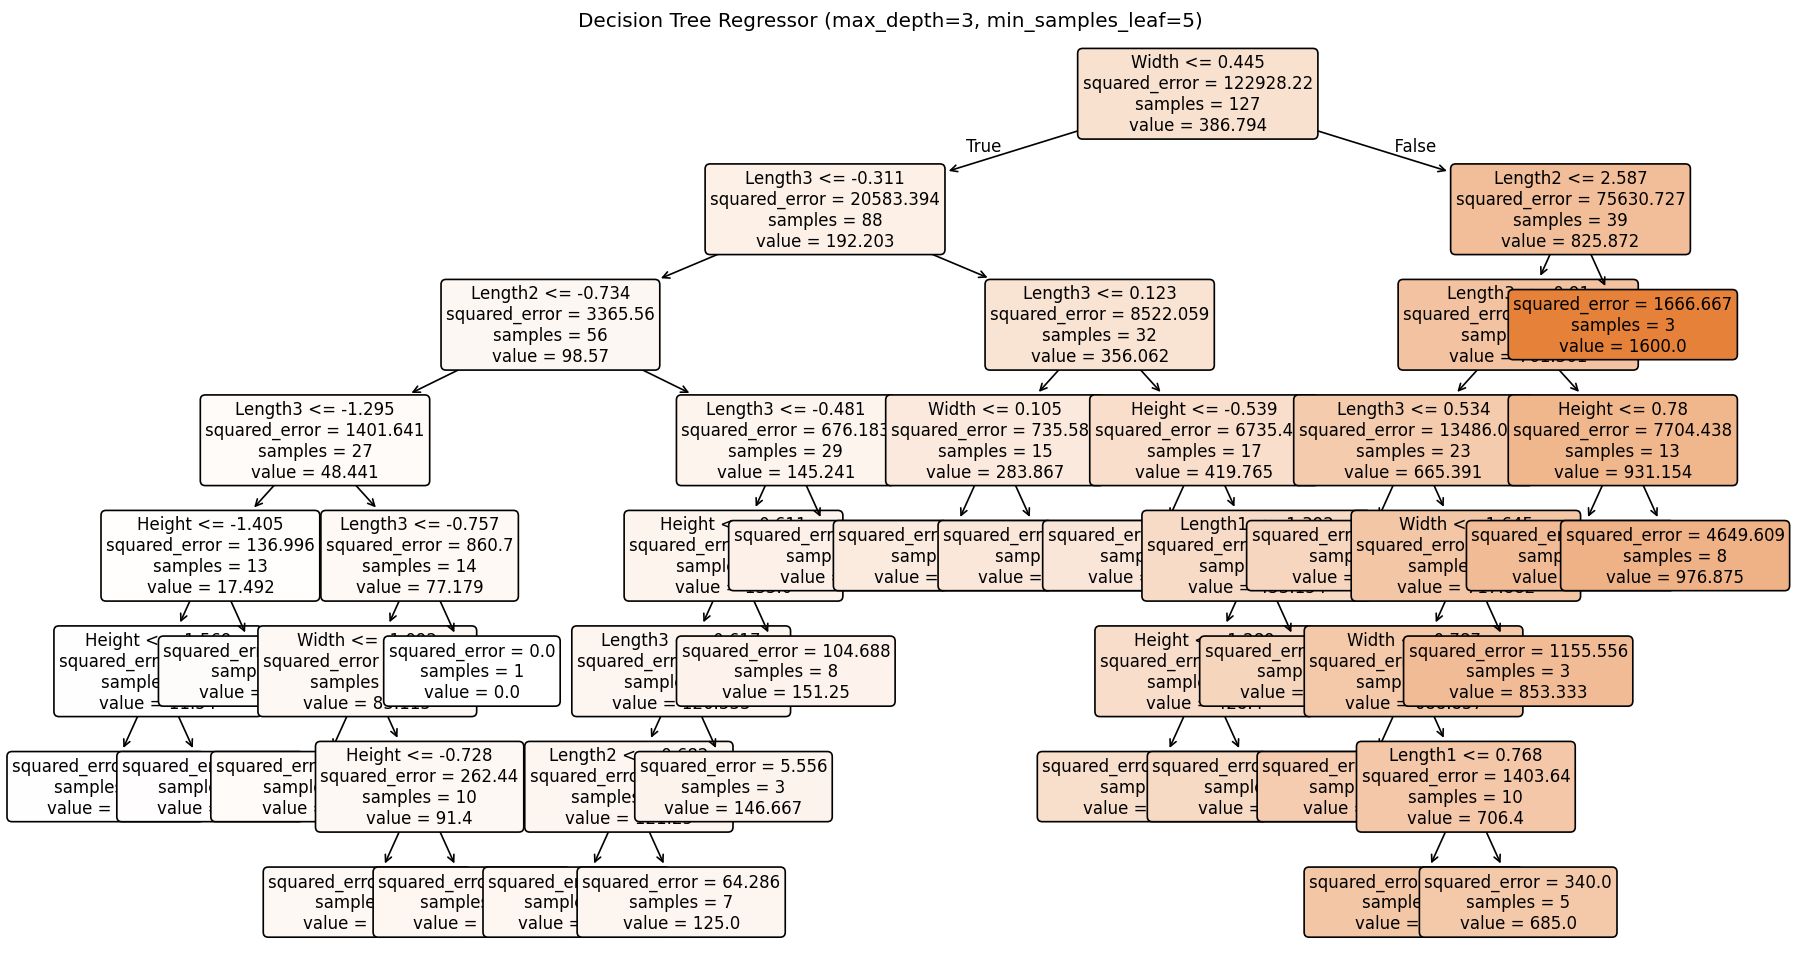

In [47]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
plt.figure(figsize=(18, 10), dpi=120)

plot_tree(
     best_Dec_t,
     feature_names=features,
     filled=True,          # colorea por valor
     rounded=True,         # nodos con bordes redondeados
     fontsize=10
)
plt.title("Decision Tree Regressor (max_depth=3, min_samples_leaf=5)")
plt.show()